# Alice Chapter 1 USB -> 20 kHz Band -> Spectrogram -> ASR

This notebook loads Alice Chapter 1 USB data, isolates a 2.5 kHz band around 20 kHz, visualizes spectrograms, demodulates for speech recovery, runs ASR transcription, and finally plays the true USB audio.

In [1]:
import os
import glob
import re
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import butter, sosfiltfilt, spectrogram, resample_poly
from IPython.display import Audio, display
import whisper

# ===== CONFIG =====
SAMPLE_RATE = 200_000
DATA_ROOTS = [
    '<REPO_ROOT>/May29_Alice',
    '<REPO_ROOT>/July10_Podcasts',
]
TARGET_CHAPTER = 1

# Band around 20 kHz with total bandwidth 2.5 kHz
CENTER_FREQ = 20_000
BANDWIDTH = 2_500
LOWCUT = CENTER_FREQ - BANDWIDTH / 2
HIGHCUT = CENTER_FREQ + BANDWIDTH / 2

# Demod/baseband settings
BASEBAND_LPF_CUTOFF = 2_500
ASR_SAMPLE_RATE = 16_000
MAX_SECONDS = 60  # process 60-second chunk

print(f'Configured bandpass: {LOWCUT:.1f} Hz to {HIGHCUT:.1f} Hz (center {CENTER_FREQ} Hz)')

Configured bandpass: 18750.0 Hz to 21250.0 Hz (center 20000 Hz)


In [3]:
def find_chapter_usb_file(target_chapter, roots):
    patterns = [
        f'*Chap_{target_chapter}_img.bin',
        f'*Chap_{target_chapter:02d}_img.bin',
        f'*chapter_{target_chapter}_img.bin',
        f'*chapter_{target_chapter:02d}_img.bin',
        '*_img.bin',
    ]

    candidates = []
    for root in roots:
        for p in patterns:
            candidates.extend(glob.glob(os.path.join(root, p)))

    # Deduplicate while preserving order
    seen = set()
    unique_candidates = []
    for c in candidates:
        if c not in seen:
            seen.add(c)
            unique_candidates.append(c)

    # Prefer exact chapter matches if possible
    exact = []
    chapter_tokens = [
        rf'chap[_-]?0*{target_chapter}(?!\d)',
        rf'chapter[_-]?0*{target_chapter}(?!\d)',
    ]

    for path in unique_candidates:
        name = os.path.basename(path).lower()
        if any(re.search(tok, name) for tok in chapter_tokens):
            exact.append(path)

    if exact:
        return exact[0]
    if unique_candidates:
        return unique_candidates[0]
    return None

usb_path = find_chapter_usb_file(TARGET_CHAPTER, DATA_ROOTS)
if usb_path is None:
    raise FileNotFoundError('No chapter USB *_img.bin file found in configured roots.')

powerline_path = usb_path.replace('_img.bin', '_real.bin')
if not os.path.exists(powerline_path):
    powerline_path = None

print(f'Selected USB file: {usb_path}')
if powerline_path:
    print(f'Matching powerline file: {powerline_path}')

Selected USB file: <REPO_ROOT>/May29_Alice/Chap_1_img.bin
Matching powerline file: <REPO_ROOT>/May29_Alice/Chap_1_real.bin


In [4]:
usb_data = np.fromfile(usb_path, dtype=np.float32)

if MAX_SECONDS is not None:
    max_samples = int(MAX_SECONDS * SAMPLE_RATE)
    usb_data = usb_data[:max_samples]

duration_sec = len(usb_data) / SAMPLE_RATE
time_axis = np.arange(len(usb_data)) / SAMPLE_RATE

print(f'Loaded USB samples: {len(usb_data):,}')
print(f'Duration: {duration_sec:.2f} seconds ({duration_sec/60:.2f} minutes)')

Loaded USB samples: 12,000,000
Duration: 60.00 seconds (1.00 minutes)


In [5]:
def bandpass_sos(x, fs, lowcut, highcut, order=4):
    nyq = fs / 2
    low = max(lowcut / nyq, 1e-6)
    high = min(highcut / nyq, 0.999999)
    sos = butter(order, [low, high], btype='band', output='sos')
    return sosfiltfilt(sos, x)

usb_band_20k = bandpass_sos(usb_data, SAMPLE_RATE, LOWCUT, HIGHCUT, order=4)
print('Bandpass filtering complete.')

Bandpass filtering complete.


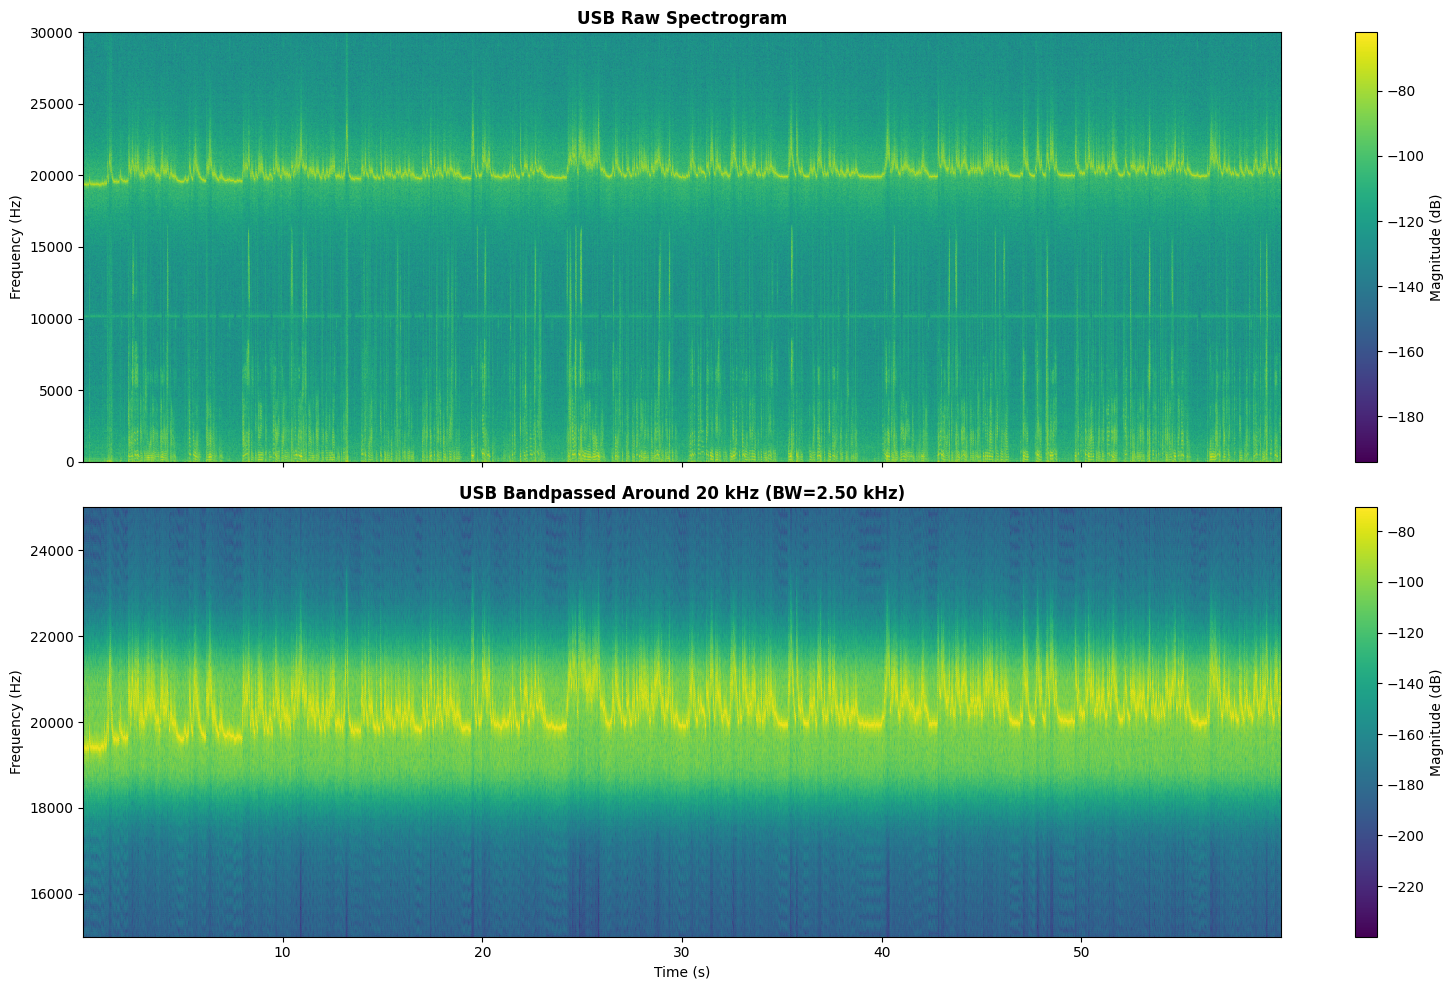

In [6]:
NFFT = 4096
NOVERLAP = NFFT // 2

f1, t1, s1 = spectrogram(usb_data, fs=SAMPLE_RATE, nperseg=NFFT, noverlap=NOVERLAP, scaling='density', mode='magnitude')
f2, t2, s2 = spectrogram(usb_band_20k, fs=SAMPLE_RATE, nperseg=NFFT, noverlap=NOVERLAP, scaling='density', mode='magnitude')

s1_db = 20 * np.log10(s1 + 1e-12)
s2_db = 20 * np.log10(s2 + 1e-12)

fig, axes = plt.subplots(2, 1, figsize=(16, 10), sharex=True)

im1 = axes[0].pcolormesh(t1, f1, s1_db, shading='gouraud', cmap='viridis')
axes[0].set_title('USB Raw Spectrogram', fontweight='bold')
axes[0].set_ylabel('Frequency (Hz)')
axes[0].set_ylim(0, 30000)
fig.colorbar(im1, ax=axes[0], label='Magnitude (dB)')

im2 = axes[1].pcolormesh(t2, f2, s2_db, shading='gouraud', cmap='viridis')
axes[1].set_title(f'USB Bandpassed Around 20 kHz (BW={BANDWIDTH/1000:.2f} kHz)', fontweight='bold')
axes[1].set_xlabel('Time (s)')
axes[1].set_ylabel('Frequency (Hz)')
axes[1].set_ylim(15000, 25000)
fig.colorbar(im2, ax=axes[1], label='Magnitude (dB)')

plt.tight_layout()
plt.show()

In [7]:
# Demodulate 20 kHz band to baseband for ASR
t = np.arange(len(usb_band_20k)) / SAMPLE_RATE
mixed_down = usb_band_20k * np.cos(2 * np.pi * CENTER_FREQ * t)

# Low-pass filter around 2.5 kHz to keep baseband speech envelope/content
nyq = SAMPLE_RATE / 2
lpf_norm = BASEBAND_LPF_CUTOFF / nyq
sos_lpf = butter(6, lpf_norm, btype='low', output='sos')
demod_baseband = sosfiltfilt(sos_lpf, mixed_down)

# Resample to ASR sample rate
up = ASR_SAMPLE_RATE
down = SAMPLE_RATE
demod_16k = resample_poly(demod_baseband, up, down).astype(np.float32)

# Normalize for ASR/audio playback
peak = np.max(np.abs(demod_16k)) + 1e-12
demod_16k = demod_16k / peak

print(f'Demodulated audio length @16k: {len(demod_16k):,} samples ({len(demod_16k)/ASR_SAMPLE_RATE:.2f}s)')
print('Preview demodulated audio (for sanity check):')
display(Audio(demod_16k, rate=ASR_SAMPLE_RATE))

Demodulated audio length @16k: 960,000 samples (60.00s)
Preview demodulated audio (for sanity check):


In [ ]:
# ASR transcription from demodulated USB
model_name = 'base'
print(f'Loading Whisper model: {model_name}')
asr_model = whisper.load_model(model_name)

asr_result = asr_model.transcribe(
    demod_16k,
    language='en',
    fp16=False,
    task='transcribe',
    no_speech_threshold=1.0,
    logprob_threshold=-2.0,
    condition_on_previous_text=False
)

transcript = asr_result.get('text', '').strip()
print('\n=== TRANSCRIPTION ===')
if transcript:
    print(transcript)
else:
    print('[Whisper returned empty text for this chunk]')
    if asr_result.get('segments'):
        print('Segment-level output:')
        for seg in asr_result['segments'][:10]:
            print(f"[{seg['start']:.2f}s - {seg['end']:.2f}s] {seg['text'].strip()}")
    else:
        print('No segments detected. Try adjusting CENTER_FREQ/BANDWIDTH or selecting a different chunk.')

Loading Whisper model: base


In [2]:
# Play true USB audio at the end
# Note: This is ultrasonic content sampled at 200 kHz; playback is for reference.
usb_playback = usb_data.astype(np.float32)
usb_peak = np.max(np.abs(usb_playback)) + 1e-12
usb_playback = usb_playback / usb_peak

print('True USB audio playback (original sampling rate):')
display(Audio(usb_playback, rate=SAMPLE_RATE))

NameError: name 'usb_data' is not defined